In [1]:
import numpy as np
from matplotlib import pyplot as plt
import netCDF4 as nc
from cmocean import cm
from scipy import signal
import seawater as sw
import geopy
import geopy.distance
#from eofs.standard import Eof
import datetime
from datetime import date
from scipy import interpolate
from os import listdir
from os.path import isfile, join
import xarray as xr
from sklearn.decomposition import PCA
import cartopy
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import cartopy.mpl.ticker as cticker
from shapely.geometry import Point, Polygon
from calendar import monthrange
from scipy import stats


def cal_path_position(path,LON1,LON2): #track path
    ####path:(ntimes,x,2)
    ###LON1 and LON2 are boundaries for region of interest with given lon boundaries
    times = path.shape[0]
    path_position = np.zeros(times)
    for k in range(times):
        path_lon = path[k,:,0][np.where(np.isnan(path[k,:,0])==0)]
        path_lat = path[k,:,1][np.where(np.isnan(path[k,:,1])==0)]
        ind = np.where((path_lon>=LON1)&(path_lon<=LON2))[0]
        path_position[k] = np.mean(path_lat[ind[0]:ind[-1]+1])     
    return path_position

def cal_path_length(path,LON1,LON2): #length of gulfstream
    ####path:(ntimes,x,2)
    ###LON1 and LON2 are boundaries for region of interest
    times = path.shape[0]
    path_length = np.zeros(times)
    for k in range(times):
        path_lon = path[k,:,0][np.where(np.isnan(path[k,:,0])==0)]
        path_lat = path[k,:,1][np.where(np.isnan(path[k,:,1])==0)]
        ind = np.where((path_lon>=LON1)&(path_lon<=LON2))[0]
        path_lon = path_lon[ind[0]:ind[-1]+1]
        path_lat = path_lat[ind[0]:ind[-1]+1]
        dist1 = 0;
        for p in range(path_lon.size-1):
            x1 = path_lon[p]; x2 = path_lon[p+1];
            y1 = path_lat[p]; y2 = path_lat[p+1];
            dist1 = dist1+sw.dist([y1,y2],[x1,x2])[0][0];
        path_length[k] = dist1;
    return path_length

def month2year(series):
    ##series(nmonths)
    nmonths = series.shape[0]
    nyears = int(nmonths/12)
    new = np.zeros(nyears)
    for n in range(nyears):
        new[n] = np.mean(series[n*12:(n+1)*12])
    return new

def month2year3d(data):
    ##data(nmonths,nlat,nlon)
    nmonths = data.shape[0]
    nyears = int(nmonths/12)
    new = np.zeros((nyears,data.shape[1],data.shape[2]))
    for n in range(nyears):
        new[n,:,:] = np.mean(data[n*12:(n+1)*12,:,:],axis=0)
    return new
ssh_ds = nc.Dataset('/Users/sydneyperkins/Downloads/SSH_data_downscaling.nc','r')


/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/3855797878.py:6: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
# lat_obs = ssh_ds.variables['lat_roms'][ilat_obs,0];
# lon_obs = ssh_ds.variables['lon_roms'][0,ilon_obs]
# print(np.min(ssh_ds.variables['lon_roms'][:]), np.max(ssh_ds.variables['lon_roms'][:]))
# print(np.min(ssh_ds.variables['lat_roms'][0,:]), np.max(ssh_ds.variables['lat_roms'][:]))
# print(ssh_ds.variables['lat_roms'].shape)
# print(ssh_ds.variables['lon_roms'].shape)
# print(lat_obs.shape)
# print(lon_obs.shape)

NameError: name 'ilat_obs' is not defined

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contourf(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/3421310205.py:26: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  seg = c.collections[0].get_paths()
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/3421310205.py:31: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  path1 = c.collections[0].get_paths()[real].vertices
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.1

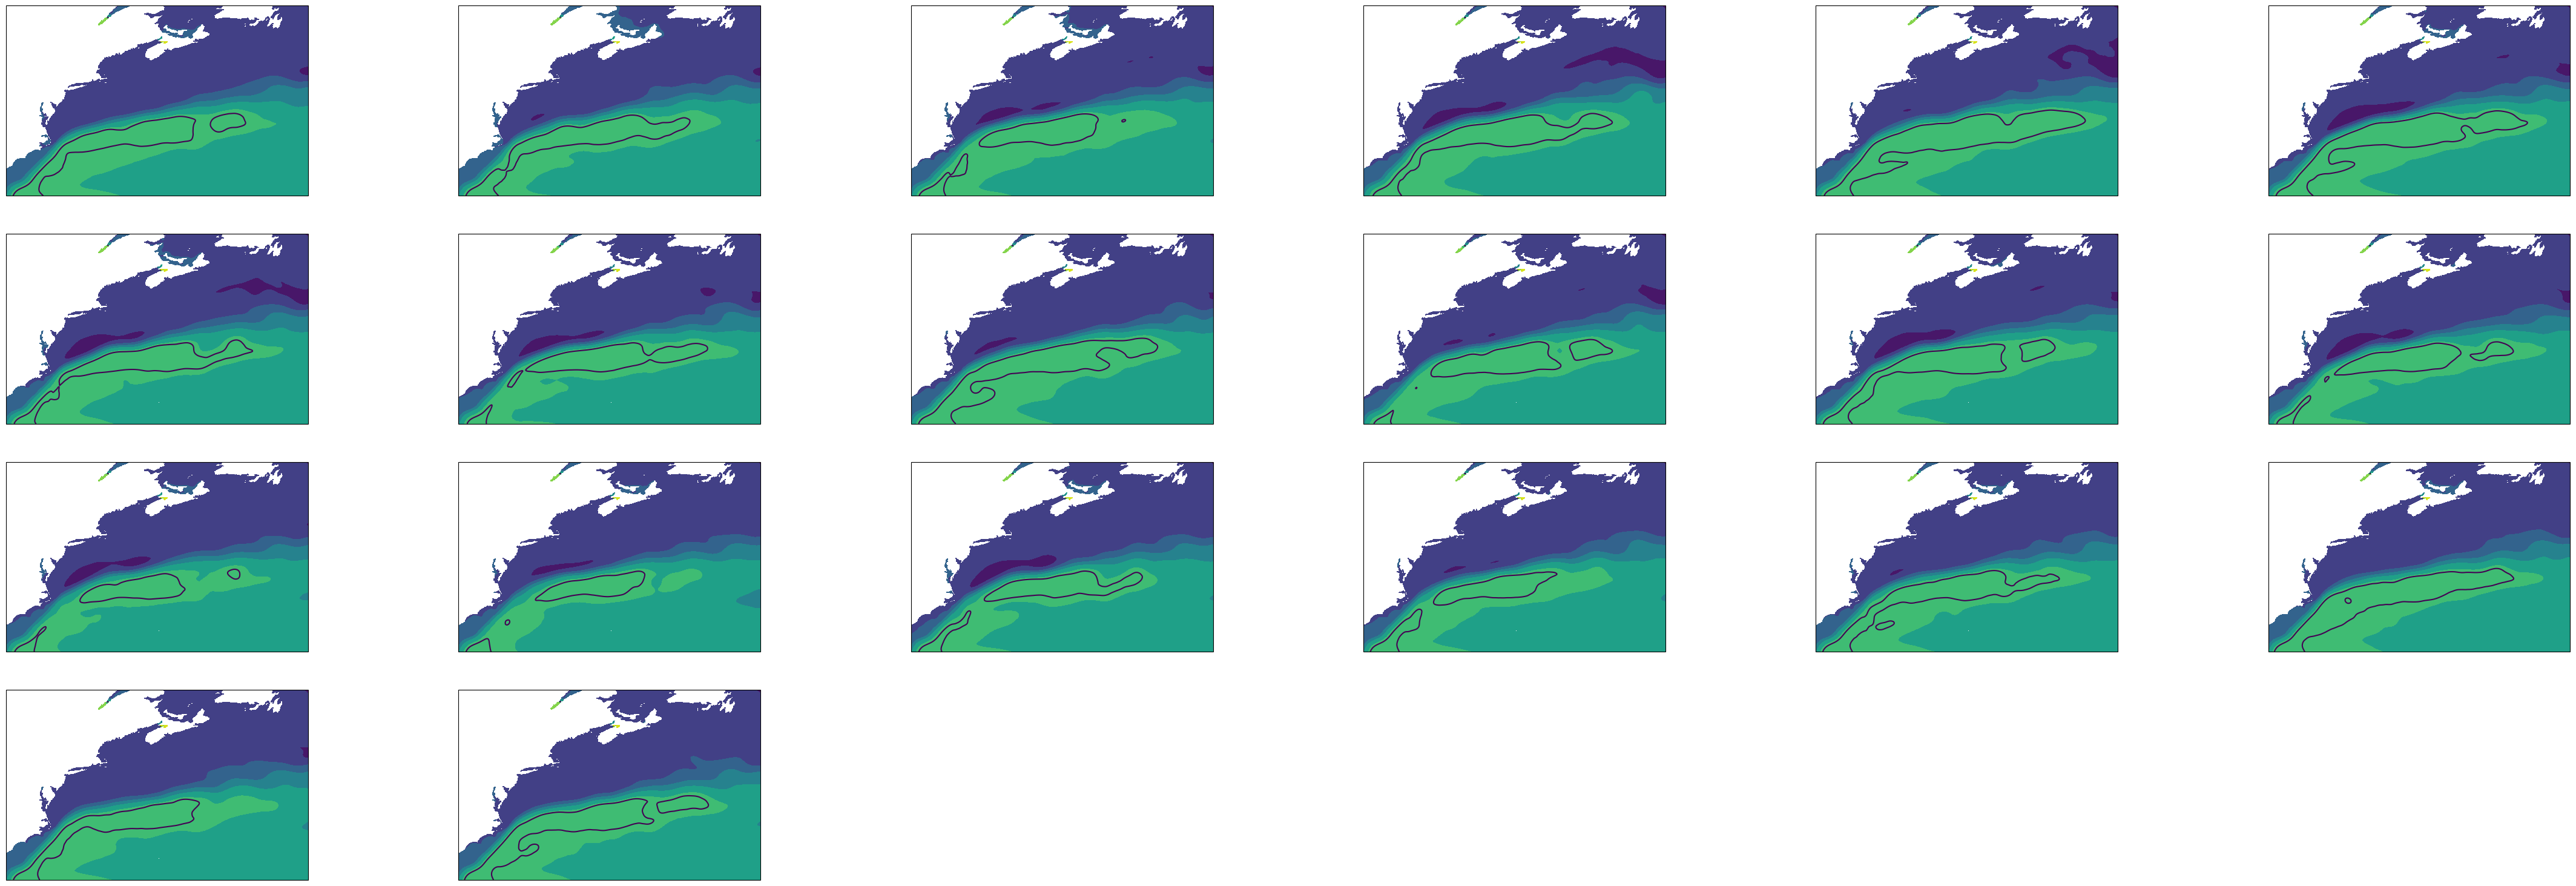

In [10]:
GS_lat1 = 30.125; GS_lat2 = 48.875;
GS_lon1 = 280.125-360; GS_lon2 = 309.875-360;
year1 = 1993; year2 = 2018;
lat0 = ssh_ds.variables['lat_roms'][:,0];
lon0 = ssh_ds.variables['lon_roms'][0,:];
ilat_obs = np.where((lat0>=GS_lat1) & (lat0<=GS_lat2))[0];
ilon_obs = np.where((lon0>=GS_lon1) & (lon0<=GS_lon2))[0];
#ssh_dataset = nc.Dataset('/Volumes/Yiming91977/Global_SSH_AVISO/Global_MONTHLY_SSH_1993_2020.nc','r')
ssh_obs_roms = ssh_ds.variables['ssh_roms'][0:(year2-year1+1)*12,0, ilat_obs,ilon_obs];
ssh_obs_glorys = ssh_ds.variables['ssh_glorys'][0:(year2-year1+1)*12,0, ilat_obs,ilon_obs];
ssh_dple = ssh_ds.variables['ssh_dple40'][0:(year2-year1+1)*12,0, ilat_obs,ilon_obs];
ssh_obs_glorys[np.where(abs(ssh_obs_roms)>10)] = np.nan
ssh_obs_mean = np.mean(ssh_obs_roms,axis=0)
lat_obs = ssh_ds.variables['lat_roms'][ilat_obs,0];
lon_obs = ssh_ds.variables['lon_roms'][0,ilon_obs];
nyears_obs = int(year2-year1+1)
nmonths_obs = ssh_obs_roms.shape[0];
path_obs = np.nan*np.zeros((ssh_obs_roms.shape[0],2000,2));   ####320 is for the longest path
ax_obs = 0.25
fig = plt.figure(figsize = (56.25,18.75)); fs=15;

for k in range(ssh_obs_roms.shape[0]):
    m=fig.add_subplot(4,6,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
    plt.contourf(lon_obs, lat_obs, ssh_obs_roms[k,:,:],color = 'seismic')
    c = plt.contour(lon_obs,lat_obs,ssh_obs_roms[k,:,:],levels=[ax_obs],color = 'seismic')
    seg = c.collections[0].get_paths()
    length = np.zeros(len(seg))
    for p in range(len(seg)):
        length[p] = seg[p].vertices.shape[0];
    real = np.where(length==max(length))[0][0]   ####choose the real path
    path1 = c.collections[0].get_paths()[real].vertices
    path_obs[k,0:path1.shape[0],:] = path1
    #plt.close();

SI_obs = cal_path_position(path_obs,LON1=285-360,LON2=290-360)
SIa_obs = month2year((SI_obs-np.mean(SI_obs))/np.std(SI_obs));
PI_obs = cal_path_position(path_obs,LON1=lon_obs[0],LON2=lon_obs[-1])
PIa_obs = month2year((PI_obs-np.mean(PI_obs))/np.std(PI_obs));

length_obs = cal_path_length(path_obs,LON1=lon_obs[0],LON2=lon_obs[-1])
length_obs = month2year((length_obs-np.mean(length_obs))/np.std(length_obs))


In [16]:
print(ssh_obs_roms.shape, ssh_obs_glorys.shape)
print(ssh_ds.variables['ssh_glorys'].shape, ssh_ds.variables['ssh_roms'].shape)

(20, 372, 843) (20, 372, 843)
(20, 8, 466, 1332) (20, 8, 466, 1332)


Text(0.5, 1.0, 'Roms, year1 ')

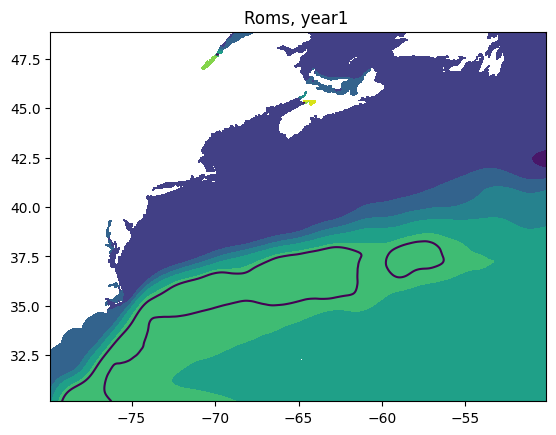

In [19]:
plt.contourf(lon_obs, lat_obs, ssh_obs_roms[0,:,:])
c = plt.contour(lon_obs,lat_obs,ssh_obs_roms[0,:,:],levels=[ax_obs])
plt.title('Roms, year1 ')
# seg = c.collections[0].get_paths()
# length = np.zeros(len(seg))
# for p in range(len(seg)):
#     length[p] = seg[p].vertices.shape[0];
# real = np.where(length==max(length))[0][0]   ####choose the real path
# path1 = c.collections[0].get_paths()[real].vertices
# path_obs[k,0:path1.shape[0],:] = path1

In [23]:
print(lat_obs.shape)

(372,)


In [ ]:
# lat_test = lat_obs
# mask = np.ma.getmaskarray(lon_obs) 
# expanded_mask = (
#     mask
#     | np.roll(mask, 1)
#     | np.roll(mask, -1)
# ) #finding neigbors 
# expanded_mask[0] = mask[0] | mask[1]
# expanded_mask[-1] = mask[-1] | mask[-2]
# lon_clean = lon_obs[~expanded_mask] 
# print(lon_clean.shape)


In [25]:
mask = np.ma.getmaskarray(lat_obs)
print(type(lat_obs))

<class 'numpy.ma.MaskedArray'>


In [26]:
f = 2* 465.2* np.sin(lat_obs*(np.pi/180))

In [28]:
print(ssh_obs_roms.shape)

(20, 372, 843)


In [31]:
# delta_lat = np.gradient(lat_obs)
# delta_lat = delta_lat[:,np.newaxis]
# delta_lon = np.gradient(lon_obs)
# delta_lon = delta_lon[np.newaxis,:]
# print(delta_lon.shape)
# print(partial_lat[0,:].shape)
# print(delta_lat.shape)
# print(partial_lon[:,0].shape)
# print(ssh_roms.shape)
# print(f.shape)
#outdated

In [32]:
delta_lat = np.gradient(lat_obs) * 111000
delta_lat = delta_lat[:,np.newaxis]
delta_lon = np.gradient(lon_obs)
delta_lon = delta_lon[np.newaxis,:]* 111000
ssh_roms = ssh_obs_roms[0,:,:]
partial_lon_r = np.gradient(ssh_roms, axis = 1)
partial_lat_r = np.gradient(ssh_roms, axis = 0)
g= 9.81
f = 2* 7.29e-5* np.sin(lat_obs*(np.pi/180))
f = f[:, np.newaxis]
#I need f to index and multiply by the lon associated with various lat

In [34]:
speed_v_r = (partial_lon_r/delta_lon)*(g/f) # partial taken over lon, then divided by delta lon
speed_u_r = (partial_lat_r/delta_lat)*(-g/f)
speed_v_sq_r = speed_v_r*speed_v_r
speed_u_sq_r = speed_u_r*speed_u_r
speed_r = np.sqrt(speed_v_sq_r+speed_u_sq_r)

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/2893239205.py:5: RuntimeWarning: invalid value encountered in sqrt
  speed_r = np.sqrt(speed_v_sq_r+speed_u_sq_r)


In [35]:
speed_r[np.where(speed_r == 0)] = np.nan
speed_r = np.ma.filled(speed_r,np.nan)
def coast_mask(data,npoints):
    data_new = np.zeros(data.shape);
    data_new[:] = data;
    data_new[np.where(data_new ==0)] = np.nan;
    for j in np.arange(npoints,lat_obs.size-npoints,1):
        for i in np.arange(npoints,lon_obs.size-npoints,1):
            if np.isnan(data[j,i])==1:
                data_new[j-npoints:j+npoints,i-npoints:i+npoints] = np.nan
    return data_new

In [37]:
idx = np.nanargmax(speed_new_r, axis=0)
x_trace = lat_obs
ytrace = speed_new_r[idx, 0]

NameError: name 'speed_new_r' is not defined

In [39]:
speed_new_r = coast_mask(speed_r, 2)

In [40]:
ytrace.shape

NameError: name 'ytrace' is not defined

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/3147032547.py:7: UserWarning: The following kwargs were not used by contour: 'linewidth'
  plt.contour(lon_obs,lat_obs,ssh_obs_roms[0,:,:],levels=[ax_obs], colors = 'b', linestyles = 'solid', linewidth = '3')


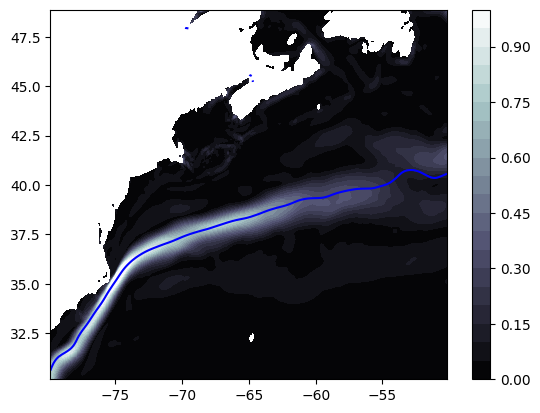

In [42]:
ax_obs = -0.15
levels = np.linspace(0,1,21)
plt.contourf(lon_obs,lat_obs,speed_new_r[:,:], levels = levels, cmap = 'bone')
plt.colorbar()
#plt.contour(lon_obs,lat_obs,speed_new_r[:,:],levels= 0, colors = 'green', linestyles = 'solid', linewidth = '7')

plt.contour(lon_obs,lat_obs,ssh_obs_roms[0,:,:],levels=[ax_obs], colors = 'b', linestyles = 'solid', linewidth = '3')
plt.show()

In [43]:
#ssh_obs_glorys
ssh_glorys_0 = ssh_obs_glorys[1,:,:]

lat_g = ssh_glorys_0[:,0]
delta_lat = np.gradient(lat_obs) * 111000
delta_lat = delta_lat[:,np.newaxis]
delta_lon = np.gradient(lon_obs)
delta_lon = delta_lon[np.newaxis,:]* 111000
partial_lon_g = np.gradient(ssh_glorys_0, axis = 1)
partial_lat_g = np.gradient(ssh_glorys_0, axis = 0)
g= 9.81
f = 2* 7.29e-5* np.sin(lat_obs*(np.pi/180))
f = f[:, np.newaxis]
#I need f to index and multiply by the lon associated with various lat
speed_v_g = (partial_lat_g/delta_lat)*(g/f)
speed_v_g = np.array(speed_v_g)
speed_u_g = (partial_lon_g/delta_lon)*(-g/f)
speed_u_g = np.array(speed_u_g)
speed_g = np.sqrt(speed_v_g**2 + speed_u_g**2)
speed_new_g = coast_mask(speed_g, 3)

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/117655818.py:6: UserWarning: The following kwargs were not used by contour: 'linewidth'
  plt.contour(lon_obs,lat_obs,ssh_obs_glorys[1,:,:],levels=[ax_obs], colors = 'g', linestyles = 'solid', linewidth = '3')


NameError: name 'lon' is not defined

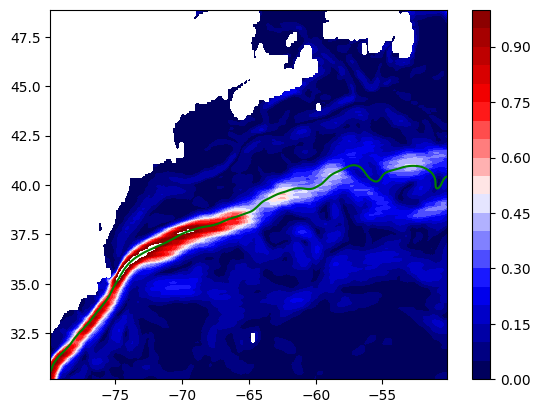

In [45]:
ax_obs = -0.15
max_g = np.max(speed_new_g)
levels = np.linspace(0,1,21)
plt.contourf(lon_obs,lat_obs,speed_new_g[:,:], levels = levels, cmap = 'seismic')
plt.colorbar()
plt.contour(lon_obs,lat_obs,ssh_obs_glorys[1,:,:],levels=[ax_obs], colors = 'g', linestyles = 'solid', linewidth = '3')
#seg = contours.collections[0].get_paths()
plt.contour(lon)
plt.show()

In [46]:
#ssh_obs_glorys
ssh_dple_0 = ssh_dple[0,:,:]
delta_lat = np.gradient(lat_obs) * 111000
delta_lat = delta_lat[:,np.newaxis]
delta_lon = np.gradient(lon_obs)
delta_lon = delta_lon[np.newaxis,:]* 111000
partial_lon_d = np.gradient(ssh_dple_0, axis = 1)
partial_lat_d = np.gradient(ssh_dple_0, axis = 0)
g= 9.81
f = 2* 7.29e-5* np.sin(lat_obs*(np.pi/180))
f = f[:, np.newaxis]
#I need f to index and multiply by the lon associated with various lat
speed_v_d = (partial_lat_d/delta_lat)*(g/f)
speed_v_d = np.array(speed_v_d)
speed_u_d = (partial_lon_d/delta_lon)*(-g/f)
speed_u_d = np.array(speed_u_d)
speed_d = np.sqrt(speed_v_d**2 + speed_u_d**2)
speed_new_d = coast_mask(speed_d, 3)

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_15009/2939195485.py:5: UserWarning: The following kwargs were not used by contour: 'linewidth'
  plt.contour(lon_obs,lat_obs,ssh_dple[1,:,:],levels=[ax_obs], colors = 'g', linestyles = 'solid', linewidth = '3')


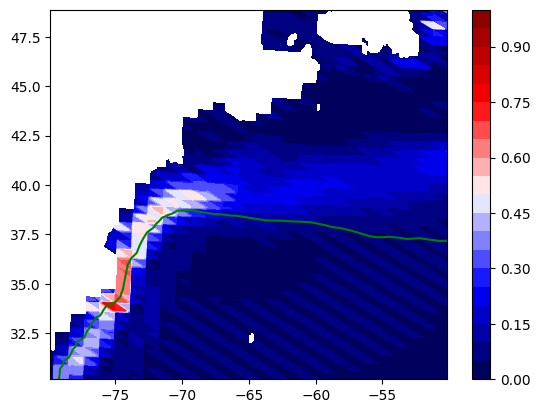

In [47]:
ax_obs = -0.2
levels = np.linspace(0,1,21)
plt.contourf(lon_obs,lat_obs,speed_new_d[:,:], levels = levels, cmap = 'seismic')
plt.colorbar()
plt.contour(lon_obs,lat_obs,ssh_dple[1,:,:],levels=[ax_obs], colors = 'g', linestyles = 'solid', linewidth = '3')
plt.show()